
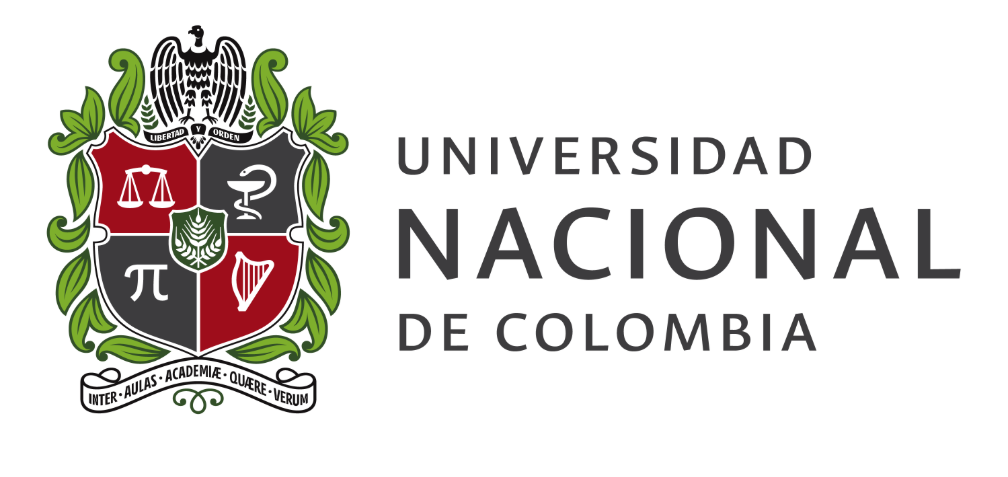
# Informe de Actividades desarrolladas Talleres 1 & 2: Sistema Experto para Diagnóstico de Piezas Mecánicas

**Universidad Nacional de Colombia** 

**Facultad de Ingeniería**

**Departamento de Ingeniería Mecánica y Mecatrónica**

**Asignatura:** Técnicas de Inteligencia Artificial

**Integrantes:**
* Sergio Andres Bolaños Penagos - sbolanosp@unal.edu.co
* Jorge Nicolas Garzón Acevedo - jngarzona@unal.edu.co
* David Santiago Pirateque Suarez - dpirateque@unal.edu.co

---

## 1. Alcance del Taller 1: Chatbot Experto y Lógica de Primer Orden (LPO)

De acuerdo con los lineamientos del taller, el proyecto consiste en el desarrollo de un chatbot experto con interfaz por voz. El sistema interactivo se diseñó para cumplir con las siguientes fases operativas:
1. **Reconocimiento de voz:** Realiza reconocimiento de voz para capturar las respuestas y mediciones del usuario mediante micrófono.
2. **Motor de Inferencia:** Procesa la información mediante un sistema experto basado en reglas en lógica de primer orden.
3. **Generación de Diagnóstico:** Genera un diagnóstico o recomendación razonada sobre el estado de la pieza.
4. **Síntesis de voz:** Presenta el resultado del dictamen final mediante síntesis de voz.

Para este proyecto, el dominio elegido es la verificación de calidad de piezas mecanizadas, cumpliendo estrictamente con los criterios exigidos:
* 8 reglas mínimo.
* Al menos 2 reglas encadenadas.
* 8 variables de entrada.
* 1 diagnóstico final no trivial.

### Definición de Predicados (Variables de Entrada)
1. `diametro_fuera(x)`: El diámetro medido de la pieza no está en el rango de tolerancia.
2. `longitud_fuera(x)`: La longitud medida de la pieza no está en el rango de tolerancia.
3. `rugosidad_excesiva(x)`: La rugosidad supera el límite máximo permitido.
4. `material_incorrecto(x)`: El material detectado no coincide con la especificación.
5. `con_grietas(x)`: Presencia visual o estructural de grietas.
6. `con_oxido(x)`: Detección de oxidación en la superficie.
7. `con_desgaste(x)`: Evidencia de desgaste físico prematuro.
8. `con_porosidad(x)`: Presencia de poros visibles en el material.

### Base de Conocimientos (Reglas y Encadenamiento)
Las reglas agrupan los predicados en fallos generales (Nivel 1) y luego encadenan estos fallos para emitir diagnósticos críticos (Nivel 2).

* **Reglas de Nivel 1 (Agrupación de hechos directos):**
  * **R1:** $\forall x (diametro\_fuera(x) \land longitud\_fuera(x) \rightarrow falla\_dimensional(x))$
  * **R2:** $\forall x (rugosidad\_excesiva(x) \land material\_incorrecto(x) \rightarrow no\_conformidad\_calidad(x))$
  * **R3:** $\forall x (con\_grietas(x) \land con\_oxido(x) \rightarrow degradacion\_severa(x))$
  * **R4:** $\forall x (con\_desgaste(x) \land rugosidad\_excesiva(x) \rightarrow defecto\_superficial(x))$

* **Reglas de Nivel 2 (Encadenamiento hacia adelante):**
  * **R5 (Encadenada):** $\forall x (falla\_dimensional(x) \land degradacion\_severa(x) \rightarrow rechazo\_absoluto(x))$
  * **R6 (Encadenada):** $\forall x (no\_conformidad\_calidad(x) \land defecto\_superficial(x) \rightarrow revision\_calidad\_requerida(x))$
  * **R7 (Encadenada):** $\forall x (degradacion\_severa(x) \land no\_conformidad\_calidad(x) \rightarrow riesgo\_fractura\_inminente(x))$
  * **R8 (Encadenada):** $\forall x (defecto\_superficial(x) \land falla\_dimensional(x) \rightarrow reproceso\_mecanico\_necesario(x))$

---

## 2. Alcance del Taller 2: Incertidumbre y Factores de Certeza (MYCIN)

De acuerdo con los requerimientos del Taller 2, el sistema no solo evalúa mediante lógica de primer orden, sino que maneja la incertidumbre acumulando evidencias parciales de fallas. Se implementaron las 4 actividades solicitadas:

### 1. Evaluación contra Tolerancias Técnicas
Se implementó una función (`evaluar_hechos_iniciales`) que recibe los parámetros físicos de la pieza extraídos del lenguaje natural y los compara contra la siguiente tabla de tolerancias base:

| Tipo | Diámetro (mm) | Longitud (mm) | Rugosidad máx (Ra) | Material |
| :--- | :--- | :--- | :--- | :--- |
| **Eje** | 49.8 – 50.2 | 99.7 – 100.3 | 2.0 | Acero |
| **Brida** | 80.0 – 80.5 | 19.5 – 20.5 | 2.0 | Aluminio |
| **Tornillo** | 9.8 – 10.2 | 19.0 – 21.0 | 1.5 | Acero |

### 2. Asignación de Factores de Certeza (FC)
Se aplicaron factores de certeza para cada evidencia de fallo detectada, integrando los pesos de la tabla suministrada dentro de las reglas lógicas. Cuando una regla requiere múltiples condiciones, el sistema calcula el FC del antecedente tomando el mínimo de las certezas de las evidencias ($\min(A, B)$) y lo multiplica por el FC de la regla.

### 3. Combinación de Evidencias (Fórmula MYCIN)
Para calcular el nivel de defecto total cuando existen múltiples fallos, se implementó una función que itera sobre los defectos derivados y los acumula usando la fórmula de combinación estándar de MYCIN:
$$FC_{total} = FC_{1} + (1 - FC_{1}) \cdot FC_{2}$$

### 4. Módulo de Salida y Diagnóstico
Para cada pieza procesada, la interfaz muestra de forma explícita:
* **Razones específicas de fallo:** Lista de conclusiones derivadas de las reglas.
* **Factor de Certeza Acumulado:** El valor numérico final del riesgo de rechazo.
* **Mensaje Final:** Un dictamen categórico y hablado que indica si la pieza debe ser aceptada, requiere revisión manual, o es rechazada categóricamente, incluyendo una recomendación técnica razonada.

In [19]:
import speech_recognition as sr
import subprocess
import re

# =====================================================================
# TALLER 1 & 2: SISTEMA EXPERTO PARA VERIFICACIÓN DE PIEZAS MECÁNICAS
# =====================================================================
# Este código cumple con:
# - 8 variables de entrada (tipo, diámetro, longitud, rugosidad, material, grietas, óxido, desgaste).
# - 8 reglas (con al menos 2 encadenadas).
# - Representación formal y Motor de Inferencia (MYCIN).
# - Reconocimiento y Síntesis de voz con diagnóstico y recomendación.


# ==========================================
# 1. BASE DE CONOCIMIENTO Y TOLERANCIAS
# ==========================================
TOLERANCIAS = {
    "eje": {"diametro": (49.8, 50.2), "longitud": (99.7, 100.3), "rugosidad": 2.0, "material": "acero"},
    "brida": {"diametro": (80.0, 80.5), "longitud": (19.5, 20.5), "rugosidad": 2.0, "material": "aluminio"},
    "tornillo": {"diametro": (9.8, 10.2), "longitud": (19.0, 21.0), "rugosidad": 1.5, "material": "acero"}
}

FC_EVIDENCIAS = {
    "diametro_fuera": 0.4,
    "longitud_fuera": 0.3,
    "rugosidad_excesiva": 0.3, 
    "material_incorrecto": 0.6,
    "con_grietas": 0.7,
    "con_oxido": 0.5,
    "con_desgaste": 0.4
}

# ==========================================
# 2. REPRESENTACIÓN FORMAL Y REGLAS LÓGICAS (Taller 1)
# ==========================================

# Representación formal en Lógica de Primer Orden (LPO) implícita:
# ∀x (FueraTolerancia(Diámetro, x) ∧ FueraTolerancia(Longitud, x) → FallaDimensional(x))


# Se definen 8 reglas. Las reglas R5 a R8 demuestran el ENCADENAMIENTO, ya que usan como condiciones las conclusiones de las reglas R1 a R4.

REGLAS = [
    # Nivel 1 (Hechos base -> Primeras conclusiones)
    {"id": "R1", "condiciones": ["diametro_fuera", "longitud_fuera"], "conclusion": "falla_dimensional", "fc": 0.6},
    {"id": "R2", "condiciones": ["rugosidad_excesiva", "material_incorrecto"], "conclusion": "no_conformidad_calidad", "fc": 0.5},
    {"id": "R3", "condiciones": ["con_grietas", "con_oxido"], "conclusion": "degradacion_severa", "fc": 0.8},
    {"id": "R4", "condiciones": ["con_desgaste", "rugosidad_excesiva"], "conclusion": "defecto_superficial", "fc": 0.4},
    
    # Nivel 2 (Conclusiones Nivel 1 -> Diagnósticos finales encadenados)
    {"id": "R5", "condiciones": ["falla_dimensional", "degradacion_severa"], "conclusion": "rechazo_absoluto", "fc": 0.95},
    {"id": "R6", "condiciones": ["no_conformidad_calidad", "defecto_superficial"], "conclusion": "revision_calidad_requerida", "fc": 0.75},
    {"id": "R7", "condiciones": ["degradacion_severa", "no_conformidad_calidad"], "conclusion": "riesgo_fractura_inminente", "fc": 0.90},
    {"id": "R8", "condiciones": ["defecto_superficial", "falla_dimensional"], "conclusion": "reproceso_mecanico_necesario", "fc": 0.65}
]

# ==========================================
# 3. EXPLICACIÓN Y MOTOR DE INFERENCIA 
# ==========================================

# EXPLICACIÓN DEL MOTOR:
# Se utiliza un enfoque de Encadenamiento Hacia Adelante (Forward Chaining).
# Parte de los hechos iniciales extraídos del texto/voz y aplica las reglas 
# iterativamente hasta que no se pueden deducir nuevos hechos. Maneja la
# incertidumbre combinando factores de certeza (FC) con las fórmulas de MYCIN.
def evaluar_hechos_iniciales(p):
    hechos = {}
    if not p["tipo"] in TOLERANCIAS: return hechos
    tol = TOLERANCIAS[p["tipo"]]

    if p["diametro"] is not None and not (tol["diametro"][0] <= p["diametro"] <= tol["diametro"][1]): 
        hechos["diametro_fuera"] = FC_EVIDENCIAS["diametro_fuera"]
    if p["longitud"] is not None and not (tol["longitud"][0] <= p["longitud"] <= tol["longitud"][1]): 
        hechos["longitud_fuera"] = FC_EVIDENCIAS["longitud_fuera"]
    if p["rugosidad"] is not None and p["rugosidad"] > tol["rugosidad"]: 
        hechos["rugosidad_excesiva"] = FC_EVIDENCIAS["rugosidad_excesiva"]
    if p["material"] and p["material"] != tol["material"]: 
        hechos["material_incorrecto"] = FC_EVIDENCIAS["material_incorrecto"]
    
    if p["grietas"]: hechos["con_grietas"] = FC_EVIDENCIAS["con_grietas"]
    if p["oxido"]: hechos["con_oxido"] = FC_EVIDENCIAS["con_oxido"]
    if p["desgaste"]: hechos["con_desgaste"] = FC_EVIDENCIAS["con_desgaste"]
    
    return hechos

def motor_inferencia_mycin(hechos_iniciales):
    hechos = hechos_iniciales.copy()
    lista_resultados = list(hechos.items()) 
    cambio = True

    while cambio:
        cambio = False
        for regla in REGLAS:
            if regla["conclusion"] not in hechos:
                if all(cond in hechos for cond in regla["condiciones"]):
                    fc_condicion = min(hechos[cond] for cond in regla["condiciones"])
                    fc_conclusion = fc_condicion * regla["fc"]
                    
                    hechos[regla["conclusion"]] = fc_conclusion
                    lista_resultados.append((regla["conclusion"], fc_conclusion))
                    cambio = True 

    fc_acumulado_rechazo = 0.0
    for _, fc in lista_resultados:
        fc_acumulado_rechazo = fc_acumulado_rechazo + (1 - fc_acumulado_rechazo) * fc

    return lista_resultados, fc_acumulado_rechazo

# ==========================================
# 4. EXTRACCIÓN DE PARÁMETROS (NLP - 8 Variables)
# ==========================================
def extraer_parametros(texto):
    texto = texto.lower()
    
    texto = texto.replace("sin embargo", "pero").replace("no obstante", "pero")
    # 8 Variables definidas en el requerimiento
    p = {
        "tipo": None, "diametro": None, "longitud": None, "rugosidad": None, 
        "material": None, "grietas": False, "oxido": False, "desgaste": False
    }

    diccionario_numeros = {
        "cincuenta y uno": "51", "ciento cinco": "105", "ciento": "100",
        "cincuenta": "50", "cien": "100", "ochenta": "80", "veinte": "20", 
        "diez": "10", "uno": "1", "dos": "2", "tres": "3", "cuatro": "4", 
        "cinco": "5", " punto ": "."
    }
    for palabra, num in diccionario_numeros.items():
        texto = texto.replace(palabra, num)

    if "eje" in texto: p["tipo"] = "eje"
    elif "brida" in texto: p["tipo"] = "brida"
    elif "tornillo" in texto: p["tipo"] = "tornillo"

    match_d = re.search(r"di[aá]metro.*?(\d+(?:[\.,]\d+)?)", texto)
    if match_d: p["diametro"] = float(match_d.group(1).replace(',', '.'))

    match_l = re.search(r"longitud.*?(\d+(?:[\.,]\d+)?)", texto)
    if match_l: p["longitud"] = float(match_l.group(1).replace(',', '.'))

    match_r = re.search(r"rugo[sc]idad.*?(\d+(?:[\.,]\d+)?)", texto)
    if match_r: p["rugosidad"] = float(match_r.group(1).replace(',', '.'))

    if "acero" in texto: p["material"] = "acero"
    elif "aluminio" in texto: p["material"] = "aluminio"

    def tiene_defecto(patron, txt):
        fragmentos = re.split(r'[\.,;]| pero | y ', txt)
        for frag in fragmentos:
            if re.search(patron, frag):
                if re.search(r"\b(sin|no tiene|no presenta|ni)\b.*?" + patron, frag):
                    return False
                return True
        return False

    p["grietas"] = tiene_defecto(r"(grieta|fisura|rota|roto)", texto)
    p["oxido"] = tiene_defecto(r"(oxido|óxido|oxidado|oxidada|oxidación)", texto)
    p["desgaste"] = tiene_defecto(r"(desgaste|desgastado|desgastada)", texto)

    return p

# ==========================================
# 5. INTERFAZ Y SÍNTESIS DE VOZ (Taller 1 y 2)
# ==========================================

def hablar(texto):
    try:
        subprocess.run(["python", "fig/Notebook/tts.py", texto])
    except Exception as e:
        print(f"[Audio output]: {texto}")

def capturar_datos():
    print("\n--- SISTEMA EXPERTO INTEGRADO: VERIFICACIÓN (T1 + T2) ---")
    opcion = input("¿Desea ingresar las mediciones por voz? (s/n): ").strip().lower()
    if opcion == 's':
        r = sr.Recognizer()
        # [NUEVO]: Esperar 2.0 segundos de silencio antes de cortar el audio
        r.pause_threshold = 2.0 
        with sr.Microphone() as source:
            hablar("Describa la pieza mecánica, sus medidas y si presenta anomalías.")
            print("\n[🎙️ Micrófono abierto] Hable ahora... (Esperando 2 segundos de silencio para terminar)")
            r.adjust_for_ambient_noise(source)
            audio = r.listen(source)
        try: return r.recognize_google(audio, language="es-ES")
        except: return None
    else:
        print("\n[⌨️ Teclado] Ej: Eje de acero con diámetro 50.5, longitud 100, y grietas.")
        return input("-> Escriba la descripción: ")


while True:
    texto_usuario = capturar_datos()

    if not texto_usuario:
        print("\n[!] No se detectó voz o no se entendió.")
        hablar("No pude escuchar con claridad. Por favor, intente hablar nuevamente.")
        continue 
    
    print(f"\n[Texto capturado]: '{texto_usuario}'")
    
    p_pieza = extraer_parametros(texto_usuario)
    print(f"[Variables extraídas]: {p_pieza}")
    
    if not p_pieza["tipo"]:
        print("[!] No se reconoció el tipo de pieza.")
        hablar("No pude reconocer el tipo de pieza. Por favor, especifique si es eje, brida o tornillo.")
        continue 
        
    else:
        # [CORRECCIÓN CRÍTICA]: Evaluamos si hay ALGÚN defecto en la información dada
        tol = TOLERANCIAS[p_pieza["tipo"]]
        
        defecto_evidente = (
            p_pieza["grietas"] or 
            p_pieza["oxido"] or 
            p_pieza["desgaste"] or
            (p_pieza["material"] is not None and p_pieza["material"] != tol["material"]) or
            (p_pieza["rugosidad"] is not None and p_pieza["rugosidad"] > tol["rugosidad"]) or
            (p_pieza["diametro"] is not None and not (tol["diametro"][0] <= p_pieza["diametro"] <= tol["diametro"][1])) or
            (p_pieza["longitud"] is not None and not (tol["longitud"][0] <= p_pieza["longitud"] <= tol["longitud"][1]))
        )
        
        # Si faltan medidas clave Y NO hemos detectado ningún defecto todavía:
        faltan_medidas = p_pieza["diametro"] is None or p_pieza["longitud"] is None
        
        if faltan_medidas and not defecto_evidente:
            print(f"[!] Información insuficiente. Faltan dimensiones clave para poder ACEPTAR la pieza.")
            hablar(f"Entendí que es una pieza tipo {p_pieza['tipo']}, pero para dar un dictamen de aprobación necesito evaluar al menos su diámetro y longitud. Por favor, repita la información completa con sus medidas.")
            continue 

        # Si pasa los filtros (ya sea porque tiene medidas completas o porque se detectó un defecto evidente), evaluamos:
        hechos_base = evaluar_hechos_iniciales(p_pieza)
        conclusiones, fc_rechazo = motor_inferencia_mycin(hechos_base)

        print("\n")
        print(f"        DIAGNÓSTICO FINAL: {p_pieza['tipo'].upper()}")
        print("-------------------------------------------------------")
        print(f"▶ Factor de certeza acumulado de rechazo: {fc_rechazo:.4f}")
        
        print("▶ Razones específicas de posible fallo:")
        razones_voz = []
        if conclusiones:
            for conc, fc in conclusiones:
                nombre_falla = conc.replace('_', ' ')
                razones_voz.append(nombre_falla)
                print(f"   - {nombre_falla.capitalize()} (Certeza: {fc:.2f})")
        else:
            print("   - Ningún defecto detectado.")

        print("-------------------------------------------------------")
        
        if fc_rechazo >= 0.5:
            texto_razones = ", ".join(razones_voz)
            print("▶ DICTAMEN: PIEZA RECHAZADA ❌")
            print("▶ RECOMENDACIÓN: Enviar a fundición para reciclaje de material.")
            hablar(f"Diagnóstico: La pieza ha sido rechazada debido a: {texto_razones}. Recomendación razonada: Debido al alto factor de certeza de fallo, se recomienda descartar la pieza inmediatamente y enviarla a fundición.")
        elif 0 < fc_rechazo < 0.5:
            texto_razones = ", ".join(razones_voz)
            print("▶ DICTAMEN: REVISIÓN MANUAL REQUERIDA ⚠️")
            print("▶ RECOMENDACIÓN: Inspección visual detallada por supervisor de planta.")
            hablar(f"Diagnóstico: La pieza requiere revisión. Se encontraron evidencias menores como: {texto_razones}. Recomendación razonada: Se recomienda apartar la pieza para una inspección visual detallada por parte del supervisor de calidad.")
        else:
            print("▶ DICTAMEN: PIEZA ACEPTADA ✅")
            print("▶ RECOMENDACIÓN: Proceder a la fase de ensamblaje.")
            hablar("Diagnóstico: La pieza cumple con todas las especificaciones dimensionales y de calidad evaluadas. Recomendación razonada: Se aprueba el componente. Se recomienda proceder directamente a la línea de ensamblaje.")
        
        break


--- SISTEMA EXPERTO INTEGRADO: VERIFICACIÓN (T1 + T2) ---

[⌨️ Teclado] Ej: Eje de acero con diámetro 50.5, longitud 100, y grietas.

[Texto capturado]: 'Eje de aluminio con presencia de grietas y óxido'
[Variables extraídas]: {'tipo': 'eje', 'diametro': None, 'longitud': None, 'rugosidad': None, 'material': 'aluminio', 'grietas': True, 'oxido': True, 'desgaste': False}


        DIAGNÓSTICO FINAL: EJE
-------------------------------------------------------
▶ Factor de certeza acumulado de rechazo: 0.9640
▶ Razones específicas de posible fallo:
   - Material incorrecto (Certeza: 0.60)
   - Con grietas (Certeza: 0.70)
   - Con oxido (Certeza: 0.50)
   - Degradacion severa (Certeza: 0.40)
-------------------------------------------------------
▶ DICTAMEN: PIEZA RECHAZADA ❌
▶ RECOMENDACIÓN: Enviar a fundición para reciclaje de material.


## 🧪 Set de Pruebas Final: Validación de Reglas de Encadenamiento

Este set de 18 pruebas verifica la extracción de parámetros y el motor de inferencia, con énfasis en el encadenamiento de nivel 2.

### 🔩 Pieza: Tornillo (D: 10, L: 20, R: 1.5, M: Acero)
1. **Aceptación:** "Es un tornillo de acero con diámetro de 10, longitud de 20 y rugosidad de 1.2"
2. **Material Incorrecto:** "Tengo un tornillo de aluminio con diámetro de 10 y longitud de 20"
3. **Defecto Crítico:** "Es un tornillo con diámetro 10 pero tiene grietas visibles"
4. **Dimensión Errónea:** "Un tornillo de acero con longitud de 25 y diámetro de 10"
5. **Falta de Información:** "Es un tornillo" *(El sistema debe pedir medidas)*
6. **[ENCADENAMIENTO R6]:** "Tornillo de aluminio con rugosidad de 2.5 y presenta mucho desgaste" 
   * *(Dispara R2 + R4 -> **R6: Revisión de calidad requerida**)*

### ⚙️ Pieza: Eje (D: 50, L: 100, R: 2.0, M: Acero)
7. **Aceptación:** "Eje de acero, diámetro 50.1, longitud 100 y rugosidad de 1.8"
8. **Rugosidad Alta:** "Eje de acero con diámetro 50 y longitud 100, pero rugosidad de 2.5"
9. **Incertidumbre:** "Es un eje con óxido y también presenta desgaste"
10. **Dimensión Crítica:** "Eje con diámetro de 52 y longitud de 105"
11. **[ENCADENAMIENTO R5]:** "Eje con diámetro de 55, longitud de 110, tiene grietas y se ve oxidado" 
    * *(Dispara R1 + R3 -> **R5: Rechazo absoluto**)*
12. **[ENCADENAMIENTO R7]:** "Eje de aluminio con presencia de grietas y óxido" 
    * *(Dispara R3 + R2 -> **R7: Riesgo de fractura inminente**)*

### ⭕ Pieza: Brida (D: 80, L: 20, R: 2.0, M: Aluminio)
13. **Aceptación:** "Brida de aluminio con diámetro 80.2, longitud de 20 y rugosidad de 1.5"
14. **Fallo Dimensional:** "Brida con diámetro de 85 y longitud de 20"
15. **Contradicción:** "Brida de aluminio sin grietas ni óxido pero diámetro 80.2"
16. **Error de Material:** "Brida de acero con rugosidad 1.0, diámetro 80.2 y longitud 20"
17. **Fallo Superficial:** "Brida con mucho desgaste y rugosidad de 3.0"
18. **[ENCADENAMIENTO R8]:** "Brida con diámetro de 85, longitud de 25, desgaste y rugosidad de 3.0" 
    * *(Dispara R4 + R1 -> **R8: Reproceso mecánico necesario**)*

## Análisis del Proyecto: Sistema Experto de Verificación Mecánica

### 1. ¿Cuál es la importancia del tema seleccionado?
La verificación de piezas mecánicas es crítica en la industria 4.0 para garantizar la seguridad estructural y reducir costos por fallos de ensamblaje. Implementar un Sistema Experto permite:
* **Estandarizar criterios:** Evita la subjetividad del inspector humano.
* **Velocidad de respuesta:** Diagnósticos instantáneos basados en mediciones y observación de defectos.
* **Precisión:** El uso de lógica difusa (Factores de Certeza) permite manejar la incertidumbre de manera matemática.

### 2. ¿Qué limitaciones presenta el reconocimiento de voz?
Durante el desarrollo se identificaron tres limitaciones principales:
* **Ambigüedad del Lenguaje:** Los usuarios pueden describir el mismo defecto con palabras distintas (ej: "grieta", "fisura", "está roto").
* **Ruidos de Entorno y Pausas:** El sistema requiere configurar umbrales de silencio (`pause_threshold`) para no cortar la entrada antes de que el operario termine de hablar.
* **Dependencia de Conectividad:** La mayoría de las librerías de reconocimiento de alta precisión (como Google Speech) requieren conexión a internet para procesar el lenguaje natural.

### 3. ¿Cómo se formaliza el lenguaje natural en lógica?
Se utiliza un proceso de **Extracción de Parámetros (NLP)** mediante Expresiones Regulares (Regex). El texto capturado se mapea a un diccionario de variables predefinidas (tipo de pieza, medidas, booleanos de defectos). Una vez extraídas, estas variables alimentan el **Motor de Inferencia**, transformando una oración informal en hechos lógicos que pueden ser evaluados contra una base de conocimientos.

### 4. ¿Qué ventajas ofrece la lógica simbólica?
* **Explicabilidad:** A diferencia de una red neuronal (caja negra), la lógica simbólica permite rastrear exactamente qué regla (`R1`, `R2`, etc.) se disparó y por qué.
* **Mantenimiento:** Es fácil agregar o modificar tolerancias y materiales sin necesidad de re-entrenar un modelo.
* **Tratamiento de Incertidumbre:** Mediante el modelo MYCIN, podemos combinar evidencias de diferentes fuentes para obtener un factor de confianza final sobre el rechazo de la pieza.

### 5. ¿Cómo escalar el sistema a un entorno industrial?
Para un despliegue real se requeriría:
* **Integración con Sensores:** En lugar de entrada manual o por voz, conectar calibres digitales y cámaras de visión artificial para extraer medidas y defectos automáticamente.
* **Base de Datos Robusta:** Migrar las reglas y tolerancias a un sistema de gestión (SQL o NoSQL) para manejar miles de tipos de piezas.
* **Hardware Embebido:** Ejecutar el motor de inferencia en dispositivos de borde (Edge Computing) para garantizar latencia cero en la línea de producción.